In [1]:
import numpy as np
import pandas as pd

In [2]:
import os
os.chdir("..")

In [3]:
# Load saved embeddings — computed once, reused across all conditions
X_train = np.load("data/processed/embeddings/X_train.npy")
y_train = np.load("data/processed/embeddings/y_train.npy")
X_cal = np.load("data/processed/embeddings/X_cal.npy")
y_cal = np.load("data/processed/embeddings/y_cal.npy")
X_test = np.load("data/processed/embeddings/X_test.npy")
y_test = np.load("data/processed/embeddings/y_test.npy")

print(f"Train:       {X_train.shape} | Positives: {y_train.sum()}")
print(f"Calibration: {X_cal.shape} | Positives: {y_cal.sum()}")
print(f"Test:        {X_test.shape} | Positives: {y_test.sum()}")

Train:       (69510, 384) | Positives: 674
Calibration: (9931, 384) | Positives: 96
Test:        (19861, 384) | Positives: 192


In [4]:
from sentence_transformers import SentenceTransformer

# Load synthetic positives
df_syn = pd.read_parquet("data/synthetic/positive_raw.parquet")
print(f"Synthetic positives to encode: {len(df_syn)}")

# Encode — reusing same frozen model for consistency
model = SentenceTransformer('all-MiniLM-L6-v2')
print("Encoding synthetic positives...")
X_syn = model.encode(df_syn['sentence'].tolist(), show_progress_bar=True)
y_syn = df_syn['label'].values

print(f"Synthetic embeddings shape: {X_syn.shape}")

c:\Users\vkamat01\hedging-txtclf-experiments\venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Synthetic positives to encode: 1924


Loading weights: 100%|██████████| 103/103 [00:00<00:00, 317.45it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Encoding synthetic positives...


Batches: 100%|██████████| 61/61 [00:16<00:00,  3.78it/s]

Synthetic embeddings shape: (1924, 384)


In [5]:
# Build augmented train set
X_train_aug = np.vstack([X_train, X_syn])
y_train_aug = np.concatenate([y_train, y_syn])

print(f"Original train:  {X_train.shape} | Positives: {y_train.sum()}")
print(f"Augmented train: {X_train_aug.shape} | Positives: {y_train_aug.sum()}")
print(f"Imbalance ratio: {(y_train_aug == 0).sum() / y_train_aug.sum():.1f}:1")

Original train:  (69510, 384) | Positives: 674
Augmented train: (71434, 384) | Positives: 2598
Imbalance ratio: 26.5:1


In [6]:
from sklearn.linear_model import LogisticRegression

# Baseline classifier
clf_base = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
clf_base.fit(X_train, y_train)
print("Baseline trained.")

# Augmented classifier — same hyperparameters for fair comparison
clf_aug = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
clf_aug.fit(X_train_aug, y_train_aug)
print("Augmented trained.")

Baseline trained.
Augmented trained.


In [7]:
from venn_abers import VennAbersCalibrator

# --- Baseline ---
y_scores_base = clf_base.predict_proba(X_test)[:, 1]
y_pred_base = clf_base.predict(X_test)

va_base = VennAbersCalibrator(estimator=clf_base, inductive=True, cal_size=None)
va_base.fit(X_cal, y_cal)
y_scores_base_cal = va_base.predict_proba(X_test)[:, 1]

# --- Augmented ---
y_scores_aug = clf_aug.predict_proba(X_test)[:, 1]
y_pred_aug = clf_aug.predict(X_test)

va_aug = VennAbersCalibrator(estimator=clf_aug, inductive=True, cal_size=None)
va_aug.fit(X_cal, y_cal)
y_scores_aug_cal = va_aug.predict_proba(X_test)[:, 1]

print("Venn-Abers calibration done — both conditions.")
print(f"\nBaseline  — raw: [{y_scores_base.min():.3f}, {y_scores_base.max():.3f}] "
      f"| calibrated: [{y_scores_base_cal.min():.3f}, {y_scores_base_cal.max():.3f}]")
print(f"Augmented — raw: [{y_scores_aug.min():.3f}, {y_scores_aug.max():.3f}] "
      f"| calibrated: [{y_scores_aug_cal.min():.3f}, {y_scores_aug_cal.max():.3f}]")

Venn-Abers calibration done — both conditions.

Baseline  — raw: [0.000, 0.999] | calibrated: [0.002, 0.538]
Augmented — raw: [0.000, 0.999] | calibrated: [0.002, 0.529]


In [8]:
from sklearn.metrics import classification_report, f1_score

def optimal_threshold_f1(y_true, y_scores, thresholds=np.arange(0.01, 0.60, 0.01)):
    """Find threshold maximizing F1 on positive class."""
    best_f1, best_t = 0, 0.5
    for t in thresholds:
        preds = (y_scores >= t).astype(int)
        f1 = f1_score(y_true, preds, zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_t = t
    return best_t, best_f1

# --- Baseline raw ---
print("=== Baseline — Raw (threshold=0.5) ===")
print(classification_report(y_test, y_pred_base, digits=3))

# --- Baseline calibrated ---
t_base_cal, _ = optimal_threshold_f1(y_test, y_scores_base_cal)
y_pred_base_cal = (y_scores_base_cal >= t_base_cal).astype(int)
print(f"=== Baseline — Calibrated (threshold={t_base_cal:.2f}) ===")
print(classification_report(y_test, y_pred_base_cal, digits=3))

# --- Augmented raw ---
print("=== Augmented — Raw (threshold=0.5) ===")
print(classification_report(y_test, y_pred_aug, digits=3))

# --- Augmented calibrated ---
t_aug_cal, _ = optimal_threshold_f1(y_test, y_scores_aug_cal)
y_pred_aug_cal = (y_scores_aug_cal >= t_aug_cal).astype(int)
print(f"=== Augmented — Calibrated (threshold={t_aug_cal:.2f}) ===")
print(classification_report(y_test, y_pred_aug_cal, digits=3))

=== Baseline — Raw (threshold=0.5) ===
              precision    recall  f1-score   support

           0      0.998     0.869     0.929     19669
           1      0.059     0.839     0.110       192

    accuracy                          0.869     19861
   macro avg      0.529     0.854     0.520     19861
weighted avg      0.989     0.869     0.921     19861

=== Baseline — Calibrated (threshold=0.11) ===
              precision    recall  f1-score   support

           0      0.992     0.989     0.990     19669
           1      0.149     0.203     0.172       192

    accuracy                          0.981     19861
   macro avg      0.571     0.596     0.581     19861
weighted avg      0.984     0.981     0.983     19861

=== Augmented — Raw (threshold=0.5) ===
              precision    recall  f1-score   support

           0      0.997     0.905     0.949     19669
           1      0.068     0.714     0.125       192

    accuracy                          0.903     19861
  

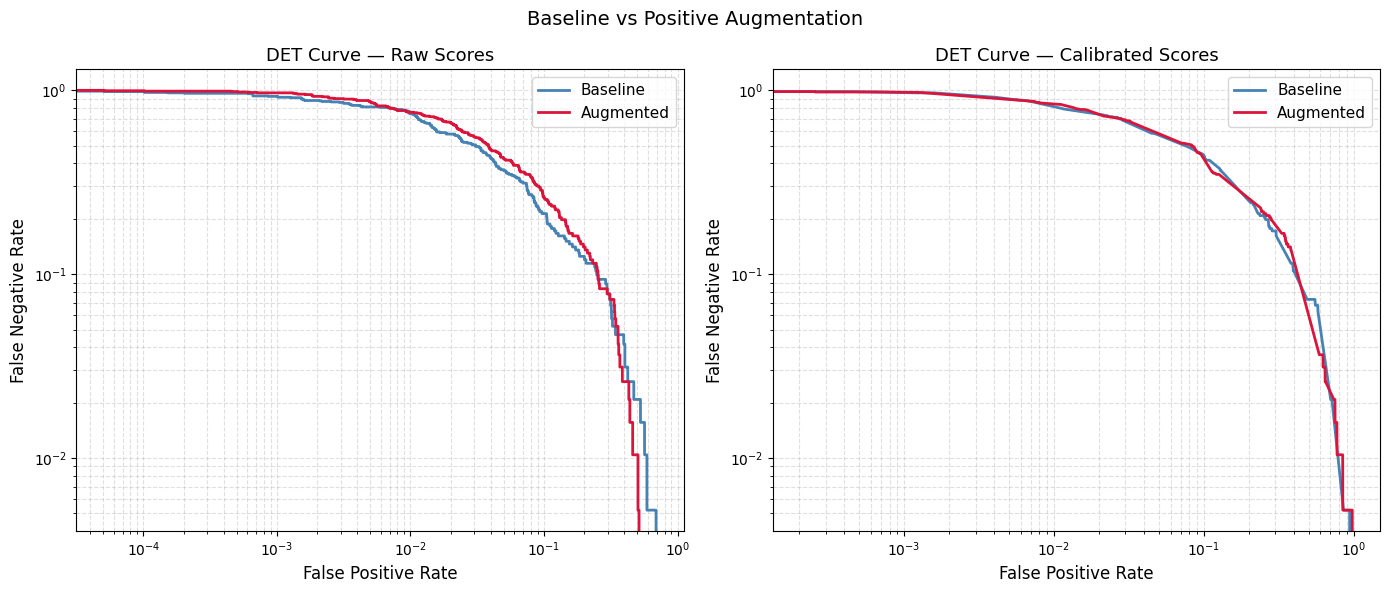

Saved.


In [9]:
import matplotlib.pyplot as plt
from sklearn.metrics import det_curve

# Compute DET curves — all four conditions
fpr_base, fnr_base, _ = det_curve(y_test, y_scores_base)
fpr_base_cal, fnr_base_cal, _ = det_curve(y_test, y_scores_base_cal)
fpr_aug, fnr_aug, _ = det_curve(y_test, y_scores_aug)
fpr_aug_cal, fnr_aug_cal, _ = det_curve(y_test, y_scores_aug_cal)

# Two separate plots — raw and calibrated
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

# Left — raw scores
ax1.plot(fpr_base, fnr_base, label='Baseline', color='steelblue', linewidth=2)
ax1.plot(fpr_aug, fnr_aug, label='Augmented', color='crimson', linewidth=2)
ax1.set_xscale('log')
ax1.set_yscale('log')
ax1.set_xlabel('False Positive Rate', fontsize=12)
ax1.set_ylabel('False Negative Rate', fontsize=12)
ax1.set_title('DET Curve — Raw Scores', fontsize=13)
ax1.legend(fontsize=11)
ax1.grid(True, which='both', linestyle='--', alpha=0.4)

# Right — calibrated scores
ax2.plot(fpr_base_cal, fnr_base_cal, label='Baseline', color='steelblue', linewidth=2)
ax2.plot(fpr_aug_cal, fnr_aug_cal, label='Augmented', color='crimson', linewidth=2)
ax2.set_xscale('log')
ax2.set_yscale('log')
ax2.set_xlabel('False Positive Rate', fontsize=12)
ax2.set_ylabel('False Negative Rate', fontsize=12)
ax2.set_title('DET Curve — Calibrated Scores', fontsize=13)
ax2.legend(fontsize=11)
ax2.grid(True, which='both', linestyle='--', alpha=0.4)

plt.suptitle('Baseline vs Positive Augmentation', fontsize=14)
plt.tight_layout()
plt.savefig("data/processed/det_curve_baseline_vs_augmented.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")

In [10]:
import umap

# --- UMAP setup ---
# Sample for visualization — all positives, random subset of negatives
# Using train set only (test/cal not revealed to model during training)

np.random.seed(42)

# Indices for real positives and negatives in train set
pos_idx = np.where(y_train == 1)[0]
neg_idx = np.where(y_train == 0)[0]

# Sample negatives — 2000 for visual clarity without overcrowding
neg_sample_idx = np.random.choice(neg_idx, size=2000, replace=False)

# Synthetic positives — all 1924
# Stack everything for UMAP fit
X_umap = np.vstack([
    X_train[pos_idx],        # real positives
    X_train[neg_sample_idx], # sampled negatives
    X_syn                    # synthetic positives
])

# Labels for coloring
labels = np.array(
    ['Real Positive'] * len(pos_idx) +
    ['Real Negative'] * len(neg_sample_idx) +
    ['Synthetic Positive'] * len(X_syn)
)

print(f"UMAP input: {X_umap.shape}")
print(f"Real positives: {len(pos_idx)}")
print(f"Real negatives (sampled): {len(neg_sample_idx)}")
print(f"Synthetic positives: {len(X_syn)}")
print("\nFitting UMAP...")

reducer = umap.UMAP(n_components=2, random_state=42, n_neighbors=30, min_dist=0.1)
embedding = reducer.fit_transform(X_umap)
print("Done.")

UMAP input: (4598, 384)
Real positives: 674
Real negatives (sampled): 2000
Synthetic positives: 1924

Fitting UMAP...


c:\Users\vkamat01\hedging-txtclf-experiments\venv\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Done.


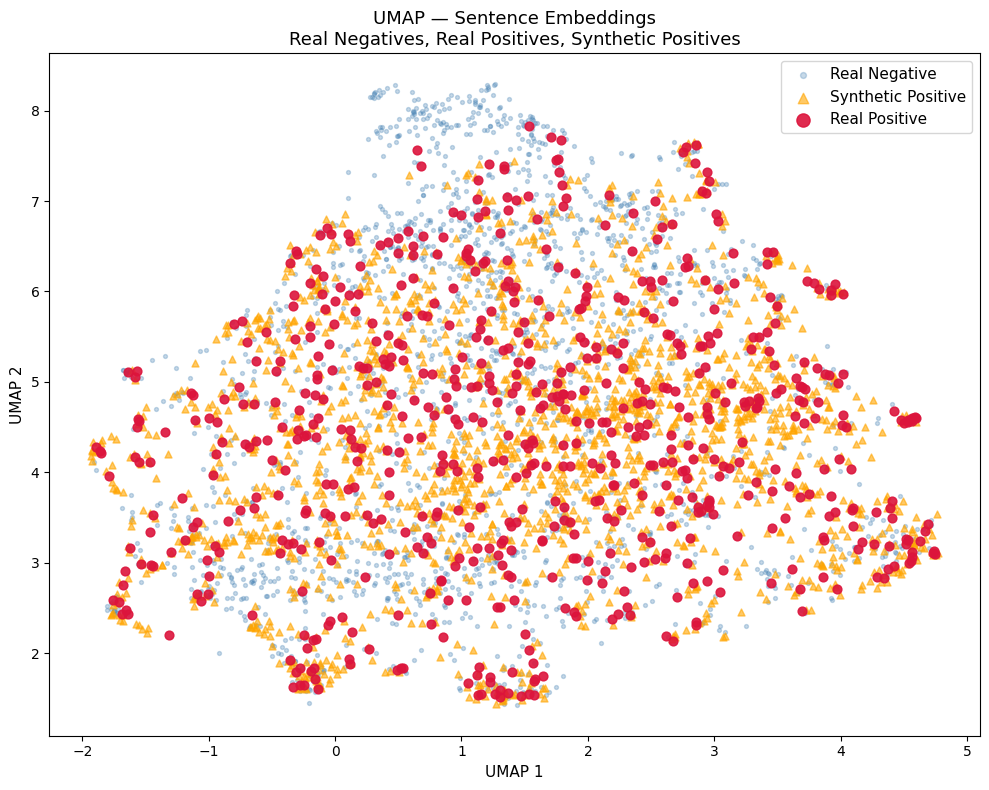

Saved.


In [11]:
# Color and marker mapping
color_map = {
    'Real Negative': 'steelblue',
    'Real Positive': 'crimson',
    'Synthetic Positive': 'orange'
}

marker_map = {
    'Real Negative': 'o',
    'Real Positive': 'o',
    'Synthetic Positive': '^'  # triangle to distinguish from real positives
}

size_map = {
    'Real Negative': 8,
    'Real Positive': 40,
    'Synthetic Positive': 25
}

alpha_map = {
    'Real Negative': 0.3,
    'Real Positive': 0.9,
    'Synthetic Positive': 0.6
}

fig, ax = plt.subplots(figsize=(10, 8))

for label in ['Real Negative', 'Synthetic Positive', 'Real Positive']:
    mask = labels == label
    ax.scatter(
        embedding[mask, 0],
        embedding[mask, 1],
        c=color_map[label],
        marker=marker_map[label],
        s=size_map[label],
        alpha=alpha_map[label],
        label=label
    )

ax.set_title('UMAP — Sentence Embeddings\nReal Negatives, Real Positives, Synthetic Positives',
             fontsize=13)
ax.legend(fontsize=11, markerscale=1.5)
ax.set_xlabel('UMAP 1', fontsize=11)
ax.set_ylabel('UMAP 2', fontsize=11)

plt.tight_layout()
plt.savefig("data/processed/umap_augmented.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved.")